In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import *

df = pd.read_csv("sales_data.csv")
df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [2]:
df[["Quantity","Price","Total_Sales"]].describe()

,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


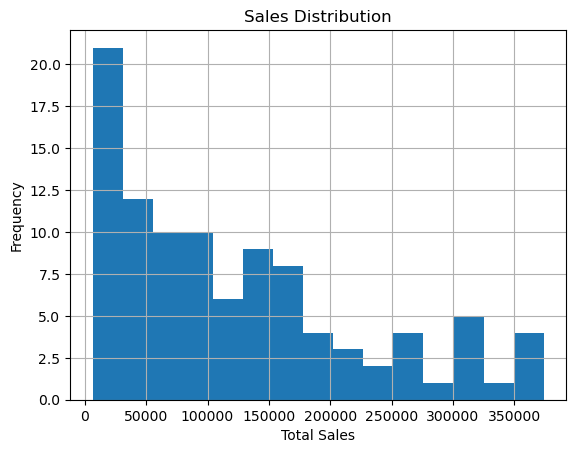

In [3]:
df["Total_Sales"].hist(bins=15)
plt.title("Sales Distribution")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()

In [4]:
shapiro(df["Total_Sales"])

ShapiroResult(statistic=0.8989262036779536, pvalue=1.2590767205714734e-06)

In [5]:
corr = df[["Quantity","Price","Total_Sales"]].corr()
print(corr)

             Quantity     Price  Total_Sales
Quantity     1.000000  0.008014     0.688107
Price        0.008014  1.000000     0.646131
Total_Sales  0.688107  0.646131     1.000000


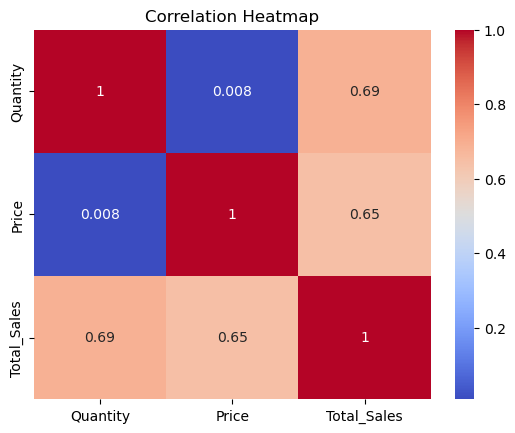

In [6]:
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [7]:
ttest_1samp(df["Total_Sales"], 100000)

TtestResult(statistic=2.36124438299242, pvalue=0.020172184232462628, df=99)

In [8]:
east = df[df["Region"]=="East"]["Total_Sales"]
west = df[df["Region"]=="West"]["Total_Sales"]
ttest_ind(east, west)

TtestResult(statistic=2.0202108796829767, pvalue=0.049619032636626016, df=43.0)

In [9]:
groups = [x["Total_Sales"] for _, x in df.groupby("Region")]
f_oneway(*groups)

F_onewayResult(statistic=2.1643634298978425, pvalue=0.09723678084980039)

In [10]:
mean = df["Total_Sales"].mean()
ci = t.interval(0.95, len(df)-1, loc=mean, scale=sem(df["Total_Sales"]))
print("Mean:", mean)
print("95% CI:", ci)

Mean: 123650.48
95% CI: (103776.34767158539, 143524.6123284146)


In [11]:
from sklearn.linear_model import LinearRegression

X = df[["Quantity"]]
y = df["Total_Sales"]

model = LinearRegression().fit(X,y)
print("R²:", model.score(X,y))
print("Coefficient:", model.coef_[0])

R²: 0.47349189833176386
Coefficient: 26629.544242716693


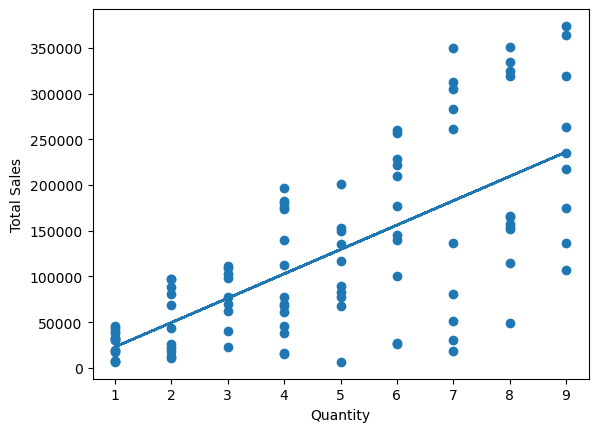

In [12]:
plt.scatter(X,y)
plt.plot(X, model.predict(X))
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.show()

In [13]:
print("Average Sales:", df["Total_Sales"].mean())
print("Best Region:", df.groupby("Region")["Total_Sales"].sum().idxmax())
print("Best Product:", df.groupby("Product")["Total_Sales"].sum().idxmax())

Average Sales: 123650.48
Best Region: North
Best Product: Laptop


In [14]:
with open("hypothesis_tests_results.txt", "w") as f:
    f.write("HYPOTHESIS TESTING RESULTS\n\n")

    f.write("Test 1: One Sample T-Test\n")
    f.write(str(ttest_1samp(df["Total_Sales"], 100000)) + "\n\n")

    f.write("Test 2: Independent T-Test (East vs West)\n")
    f.write(str(ttest_ind(east, west)) + "\n\n")

    f.write("Test 3: One-Way ANOVA\n")
    f.write(str(f_oneway(*groups)) + "\n")

print("TXT file created successfully!")

TXT file created successfully!
